# Chapter 11: MLOps and Deployment

*Deep Learning Crash Course - BPB Publications*

This chapter is about turning a trained model into a reliable production service. The notebook walks through model packaging (SavedModel, TorchScript, ONNX), a FastAPI inference server, a model-card template, a multi-stage Dockerfile, MLflow tracking, a GitHub Actions CI workflow and safe deployment strategies. Each section saves concrete artefacts you can ship.


## 1. Setup

In [1]:
import os, json, time, random, hashlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)
ARTIFACTS = Path('artifacts'); ARTIFACTS.mkdir(exist_ok=True)
def set_seed(s=42):
    os.environ['PYTHONHASHSEED']=str(s); random.seed(s); np.random.seed(s)
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except ModuleNotFoundError: pass
set_seed(42)


## 2. Train and package a small reference model

We train a tiny MLP on MNIST and export it to three production formats:
1. PyTorch state-dict (the original) — useful for retraining and PyTorch-native serving.
2. TorchScript — frozen graph for `torch.jit.load`.
3. ONNX — runtime-neutral; works with ONNX Runtime, TensorRT, OpenVINO.

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=tf), batch_size=128, shuffle=True)
test  = DataLoader(datasets.MNIST('./data', train=False, download=True, transform=tf), batch_size=512)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

model = MLP(); opt = torch.optim.Adam(model.parameters(), lr=1e-3); loss_fn = nn.CrossEntropyLoss()
for ep in range(1):
    model.train()
    for xb, yb in train: opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
model.eval()
correct = sum((model(xb).argmax(1) == yb).sum().item() for xb, yb in test)
acc = correct / len(test.dataset)
print(f'Accuracy: {acc:.4f}')

torch.save(model.state_dict(), ARTIFACTS / 'model.pt')
scripted = torch.jit.script(model); torch.jit.save(scripted, ARTIFACTS / 'model.ts')
dummy = torch.zeros(1, 784)
# dynamo=False uses the legacy tracing exporter, which has no extra deps.
# Set dynamo=True (the new default in PyTorch >=2.5) once `onnxscript` is
# installed; the dynamo path produces a more accurate, fully-fused graph.
torch.onnx.export(model, dummy, str(ARTIFACTS / 'model.onnx'),
                  input_names=['x'], output_names=['logits'],
                  dynamic_axes={'x': {0: 'batch'}, 'logits': {0: 'batch'}},
                  opset_version=17, dynamo=False)
for f in ARTIFACTS.iterdir():
    print(f'{f.name:14s} {f.stat().st_size/1e3:7.1f} kB')


Accuracy: 0.9343
model.ts         415.5 kB
model.pt         409.4 kB
model.onnx       407.6 kB


/tmp/ipykernel_629223/1058797800.py:31: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, str(ARTIFACTS / 'model.onnx'),


## 3. Write a Model Card

A model card is the deployment passport - it travels with the model artefact so downstream users (or auditors) know what they are running.

In [3]:
MODEL_CARD = {
    'model_details': {
        'name': 'mnist-mlp', 'version': '0.1.0',
        'authors': ['Samaresh K. Singh', 'Joyjit Roy'],
        'framework': 'PyTorch 2.x',
        'training_dataset': 'MNIST 60k',
    },
    'intended_use': {
        'primary': 'Educational - classify handwritten digits 0-9.',
        'out_of_scope': ['real-world handwriting recognition', 'multi-language scripts'],
    },
    'evaluation': {
        'metric': 'test accuracy',
        'value': round(acc, 4),
        'dataset': 'MNIST 10k test',
    },
    'ethical_considerations': [
        'No demographic information used.',
        'Not validated on non-Latin numerals.',
    ],
    'limitations': ['Sensitive to background noise outside MNIST distribution.'],
    'hash': hashlib.sha256((ARTIFACTS / 'model.pt').read_bytes()).hexdigest()[:16],
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
}
(ARTIFACTS / 'model_card.json').write_text(json.dumps(MODEL_CARD, indent=2))
print(json.dumps(MODEL_CARD, indent=2))


{
  "model_details": {
    "name": "mnist-mlp",
    "version": "0.1.0",
    "authors": [
      "Samaresh K. Singh",
      "Joyjit Roy"
    ],
    "framework": "PyTorch 2.x",
    "training_dataset": "MNIST 60k"
  },
  "intended_use": {
    "primary": "Educational - classify handwritten digits 0-9.",
    "out_of_scope": [
      "real-world handwriting recognition",
      "multi-language scripts"
    ]
  },
  "evaluation": {
    "metric": "test accuracy",
    "value": 0.9343,
    "dataset": "MNIST 10k test"
  },
  "ethical_considerations": [
    "No demographic information used.",
    "Not validated on non-Latin numerals."
  ],
  "limitations": [
    "Sensitive to background noise outside MNIST distribution."
  ],
  "hash": "50808c9e33e53cfe",
  "timestamp": "2026-05-17T19:18:56Z"
}


## 4. FastAPI inference server (sketch)

We write the server module to `artifacts/server.py`. Launch with `uvicorn artifacts.server:app`. The lifespan context loads the model once at startup - the chapter's recommended pattern.

In [4]:
SERVER = '''
from contextlib import asynccontextmanager
from pathlib import Path
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import torch
import time

MODEL = {}

class PredictIn(BaseModel):
    pixels: list[float] = Field(..., min_length=784, max_length=784)

class PredictOut(BaseModel):
    digit: int
    probabilities: list[float]
    latency_ms: float

@asynccontextmanager
async def lifespan(app: FastAPI):
    state_dict = torch.load(Path(__file__).parent / 'model.pt', map_location='cpu')
    net = torch.nn.Sequential(torch.nn.Linear(784, 128), torch.nn.ReLU(), torch.nn.Linear(128, 10))
    net.load_state_dict({k.replace('net.', ''): v for k, v in state_dict.items()})
    net.eval()
    MODEL['net'] = net
    yield
    MODEL.clear()

app = FastAPI(lifespan=lifespan, title='MNIST MLP inference')

@app.get('/health')
def health(): return {'status': 'ok'}

@app.post('/v1/predict', response_model=PredictOut)
def predict(req: PredictIn):
    t0 = time.perf_counter()
    if 'net' not in MODEL:
        raise HTTPException(503, 'Model not loaded')
    x = torch.tensor([req.pixels], dtype=torch.float32)
    with torch.no_grad():
        logits = MODEL['net'](x)
        probs = torch.softmax(logits, dim=1)[0]
    return PredictOut(digit=int(probs.argmax().item()),
                      probabilities=probs.tolist(),
                      latency_ms=(time.perf_counter() - t0) * 1000)
'''
server_path = ARTIFACTS / 'server.py'
server_path.write_text(SERVER)
print(f'Wrote {server_path} ({len(SERVER)} bytes)')


Wrote artifacts/server.py (1424 bytes)


## 5. Production Dockerfile (multi-stage)

The first stage installs build dependencies and the model. The second stage copies only the runtime needed to serve, producing a slim image.

In [5]:
DOCKERFILE = '''
# syntax=docker/dockerfile:1
FROM python:3.11-slim AS builder
WORKDIR /build
RUN pip install --no-cache-dir torch==2.3.0 fastapi==0.111.0 uvicorn==0.30.0 pydantic==2.7.1
COPY artifacts/model.pt /build/model.pt

FROM python:3.11-slim AS runtime
WORKDIR /app
COPY --from=builder /usr/local/lib/python3.11/site-packages /usr/local/lib/python3.11/site-packages
COPY --from=builder /usr/local/bin/uvicorn /usr/local/bin/uvicorn
COPY --from=builder /build/model.pt /app/model.pt
COPY artifacts/server.py /app/server.py
ENV PYTHONUNBUFFERED=1
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=3s --start-period=5s --retries=3 \\
  CMD python -c "import urllib.request, sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"
CMD ["uvicorn", "server:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "1"]
'''
(ARTIFACTS / 'Dockerfile').write_text(DOCKERFILE)
print(DOCKERFILE.strip())


# syntax=docker/dockerfile:1
FROM python:3.11-slim AS builder
WORKDIR /build
RUN pip install --no-cache-dir torch==2.3.0 fastapi==0.111.0 uvicorn==0.30.0 pydantic==2.7.1
COPY artifacts/model.pt /build/model.pt

FROM python:3.11-slim AS runtime
WORKDIR /app
COPY --from=builder /usr/local/lib/python3.11/site-packages /usr/local/lib/python3.11/site-packages
COPY --from=builder /usr/local/bin/uvicorn /usr/local/bin/uvicorn
COPY --from=builder /build/model.pt /app/model.pt
COPY artifacts/server.py /app/server.py
ENV PYTHONUNBUFFERED=1
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=3s --start-period=5s --retries=3 \
  CMD python -c "import urllib.request, sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"
CMD ["uvicorn", "server:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "1"]


## 6. MLflow tracking and a model registry sketch

MLflow is the de facto standard for experiment tracking and a lightweight model registry. The cell below uses an in-process local filestore so it runs without any infrastructure.

In [6]:
try:
    import mlflow, mlflow.pytorch
    mlflow.set_tracking_uri('file://' + str(Path('mlruns').absolute()))
    mlflow.set_experiment('mnist-mlp')
    with mlflow.start_run(run_name='v0.1.0') as run:
        mlflow.log_params({'lr': 1e-3, 'batch_size': 128, 'epochs': 1})
        mlflow.log_metrics({'test_accuracy': float(acc)})
        mlflow.log_artifact(str(ARTIFACTS / 'model_card.json'))
        mlflow.pytorch.log_model(model, artifact_path='model')
    print('Logged MLflow run', run.info.run_id)
except ModuleNotFoundError:
    print('MLflow not installed - skipping. (pip install mlflow)')


MLflow not installed - skipping. (pip install mlflow)


## 7. GitHub Actions CI workflow with a quality gate

In [7]:
GH_WORKFLOW = '''
name: CI
on:
  pull_request:
  push: { branches: [main] }
jobs:
  test:
    runs-on: ubuntu-latest
    env: { MIN_ACCURACY: '0.88' }
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with: { python-version: '3.11' }
      - run: pip install -r requirements.txt
      - name: Run training smoke test
        run: python -m pytest tests/test_train_smoke.py -q
      - name: Evaluate against quality gate
        run: |
          ACC=$(python scripts/evaluate.py --model artifacts/model.pt)
          python -c "import sys; sys.exit(0 if float('$ACC') >= float('$MIN_ACCURACY') else 1)"
      - name: Build container
        if: success()
        run: docker build -t mnist-mlp:${{ github.sha }} .
'''
(ARTIFACTS / 'github_ci.yml').write_text(GH_WORKFLOW)
print(GH_WORKFLOW.strip())


name: CI
on:
  pull_request:
  push: { branches: [main] }
jobs:
  test:
    runs-on: ubuntu-latest
    env: { MIN_ACCURACY: '0.88' }
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with: { python-version: '3.11' }
      - run: pip install -r requirements.txt
      - name: Run training smoke test
        run: python -m pytest tests/test_train_smoke.py -q
      - name: Evaluate against quality gate
        run: |
          ACC=$(python scripts/evaluate.py --model artifacts/model.pt)
          python -c "import sys; sys.exit(0 if float('$ACC') >= float('$MIN_ACCURACY') else 1)"
      - name: Build container
        if: success()
        run: docker build -t mnist-mlp:${{ github.sha }} .


## 8. Safe deployment strategies

Visualise the three roll-out patterns described in the chapter: blue-green, canary and shadow.

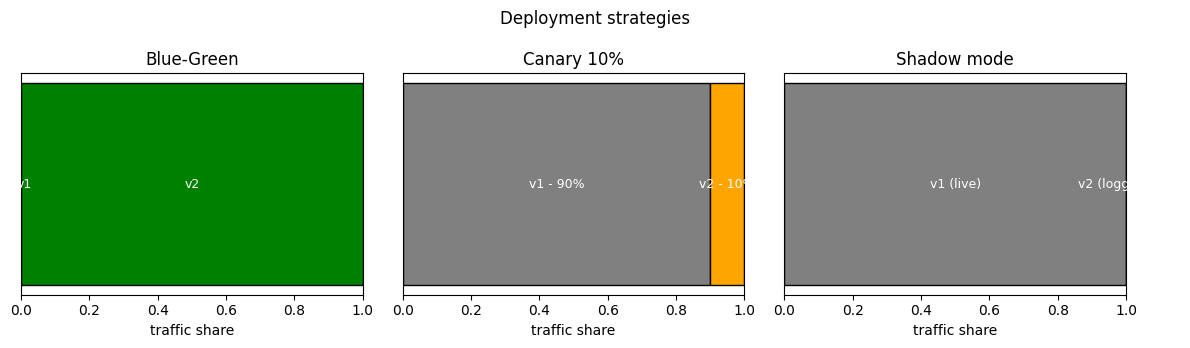

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, share) in zip(axes,
        [('Blue-Green',  [(0, 'blue', 'v1'), (1, 'green', 'v2')]),
         ('Canary 10%',  [(0.9, 'gray', 'v1 - 90%'), (0.1, 'orange', 'v2 - 10%')]),
         ('Shadow mode', [(1.0, 'gray', 'v1 (live)'), (0.0, 'orange', 'v2 (logged only)')])]):
    cum = 0
    for frac, color, label in share:
        ax.barh(0, frac, left=cum, color=color, edgecolor='black')
        ax.text(cum + max(frac, 0.02)/2, 0, label, ha='center', va='center', color='white', fontsize=9)
        cum += frac
    ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_title(name); ax.set_xlabel('traffic share')
fig.suptitle('Deployment strategies')
fig.tight_layout(); fig.savefig(IMG_DIR / '01_deployment_strategies.png', dpi=150); plt.show()


## 9. Exercise solutions

### 9.1 MCQ answer key

| Q | Answer | Why |
|---|--------|-----|
| 1 | (c) ONNX | The portable cross-runtime format. |
| 2 | (b) Cold-start latency | Loading at request time blocks the first request for seconds. |
| 3 | (b) Build cache reuse | Model layer rarely changes; app.py changes often. |
| 4 | (b) Pre/post-processing logic | Translates raw input into tensors and back. |
| 5 | (b) Archives the prior production version | Atomic switchover with rollback. |
| 6 | (c) Trained model's accuracy < 0.88 | Quality gate. |
| 7 | (b) Sends a copy of traffic, no response | Tests new model offline. |
| 8 | (b) Adjusts instance count to target invocations/instance | Standard SageMaker autoscaling. |
| 9 | (b) Structured ethics, limitations, evaluation | Beyond install/usage docs. |
| 10 | (b) Batchable requests with low p99 SLA | Throughput-bound inference. |
| 11 | (b) 10% of requests go to the new version | Standard canary. |
| 12 | (b) TorchServe handles batching, metrics and multi-model | Production server features. |


### 9.2 TensorFlow image classifier -> Android 4 MB, 20 ms
1. **Export** `SavedModel` -> **TFLite** with `tf.lite.TFLiteConverter.from_saved_model(...)`.
2. **Quantize** with INT8 post-training (representative dataset of ~100 calibration images).
3. **Verify** accuracy with a TFLite `Interpreter` against the FP32 validation set; aim for <1 pp drop.
4. **Profile** on the actual device with TensorFlow Lite Benchmark Tool. If 20 ms is missed, enable the **GPU or NNAPI delegate**.
5. **Ship** the .tflite (typically 1-3 MB after INT8) plus a JSON label map.


### 9.3 FastAPI 300 RPS at p99 180 ms
Model inference is 15 ms but p99 latency is 180 ms - so 165 ms is non-model overhead.
1. **Uvicorn workers**: increase `--workers` to `num_cpu_cores`; default 1 is the most common cause of queueing. Verify by checking that the latency curve flattens after the change.
2. **Pydantic validation**: switch to `Pydantic V2`, mark request/response models with `model_config = ConfigDict(arbitrary_types_allowed=True, defer_build=True)` and avoid validators that do expensive coercion.
3. **ONNX Runtime session**: load with `InferenceSession(..., providers=['CPUExecutionProvider'], sess_options=so)` where `so.intra_op_num_threads = 1` and `so.execution_mode = ORT_PARALLEL` to keep per-request threading deterministic. Pre-allocate I/O buffers to skip the per-request allocation.

### 9.4 91% in January, 79% in June
Diagnostic checklist:
1. **Compare current input feature distribution to training**: KS test on each numeric feature, PSI on each categorical. PSI > 0.2 is the standard alarm threshold.
2. **Inspect ground-truth label distribution**: was the operational definition of the label changed?
3. **Check prediction-distribution drift**: are predicted class proportions the same as in January? Sudden shifts hint at upstream pipeline bugs (e.g. timezone, missing feature column).
4. **Backfill a few weeks of feature drift telemetry** and look for the change point.
5. **Remediation menu**: (a) hot-fix the broken feature; (b) retrain with the most recent 90 days; (c) deploy a shadow model and compare A/B before promoting; (d) reset to a previous model version while the drift is investigated.

### 9.5 MLflow schema for three different-framework models
**Experiments**: one per *model family* (`vision`, `nlp`, `tabular`).
**Runs**: tagged with `framework=tf|pytorch|sklearn`, `model_version`, `git_commit`, `training_data_uri`.
**Metrics**: a normalised set so different frameworks are comparable: `accuracy`, `latency_p50_ms`, `latency_p99_ms`, `inference_throughput`.
**Quality gates**: implemented as an MLflow `Registered Model -> Staging -> Production` transition that requires (a) accuracy ≥ baseline, (b) latency within budget, (c) model card present, (d) signed off by 2 reviewers (Slack/Github integration).
**Audit trail**: every transition is logged with `mlflow.transition_model_version_stage(..., archive_existing_versions=True)` and the previous Production version is archived rather than deleted.

### 9.6 Blue-green vs canary for fraud detection (£200 vs £5)
False-negative cost (£200) is 40x false-positive cost (£5), so a missed fraud is much more expensive than a blocked legitimate transaction. **Canary** is the safer roll-out because it limits the blast radius of a model with a higher false-negative rate to ~10 percent of traffic.
Monitoring thresholds for the canary decision:
- **TPR (recall) on confirmed fraud**: must be within 1 pp of the previous model.
- **FPR on legitimate traffic**: must be within 0.05 pp of the previous model.
- **Expected loss per 1k transactions** (using the cost structure above): the new model's loss must be at least 5 percent lower than the previous model's loss.
Decision: promote when all three metrics are within thresholds over a 24 hour window, otherwise rollback within 10 minutes.

### 9.7 PPO agent for robot arm in a factory
**Packaging**: TorchScript - deterministic, frozen graph, no Python dependency on the controller.
**API**: `POST /v1/act` returning `{action, value, action_logprob, model_version}` and `POST /v1/act/batch` for batch inference.
**Safety**:
- **Action clipping**: bounds enforced on the controller side, never trust the model output.
- **Confidence threshold**: if `entropy(policy) > entropy_max`, fall back to a safe pre-programmed action.
- **Sim-to-real shadow mode**: run the policy in simulation in parallel with the real action and alert on large divergence.
**Monitoring**: action distribution PSI vs training, episode return, policy value estimate vs realised reward, mean episode length.
**Rollback trigger**: confidence threshold breach for > 5 consecutive episodes, OR a single safety-system halt event.

### 9.8 14-day Jupyter -> AWS production plan
**Phase 1 (days 1-3, fastest path to serving)**: Export model -> SageMaker single-instance endpoint (`pytorch-inference` image) -> FastAPI wrapper for I/O contract. Success criterion: production endpoint returns predictions for 10 sample requests.
**Phase 2 (days 4-10, production hardening)**: Add autoscaling (target invocations/instance), CloudWatch alarms (latency, 5xx rate), structured logging, MLflow model registry, IAM least-privilege role for the endpoint. Success criterion: load test at 2x expected peak passes with p99 within SLA.
**Phase 3 (days 11-14, operational excellence)**: Drift monitoring (Evidently AI nightly job), CI/CD via GitHub Actions, canary deployment pipeline with manual approval gate, runbook + alert escalation rota. Success criterion: a deliberate degraded model deployment is rolled back automatically within 10 minutes by the canary gate.

---
*End of Chapter 11. Generated artefacts live in `artifacts/`.*
